# CTGAN notebook demo

We split the sample transactions into 60% training, 20% validation, and 20% test subsets,
train SDV's CTGAN on the training split, and compare the generated output
against every subset plus the pipeline's default diagnostics.


In [1]:
import torch
print(torch.__version__)
print("PyTorch built with CUDA:", torch.version.cuda)

2.9.0+cu126
PyTorch built with CUDA: 12.6


In [2]:
import json
import sys
import warnings
from pathlib import Path
warnings.filterwarnings(
    'ignore',
    message='PerformanceAlert: Using the CTGANSynthesizer.*',
)

from IPython.display import JSON, Image, display
repo_root = Path.cwd().resolve().parents[0]
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))
from transaction_gan.config import SchemaConfig
from transaction_gan.gan import GANTrainingConfig
from transaction_gan.pipeline import generate_synthetic_transactions


In [3]:
data_path = repo_root / 'data' / 'sample_transactions.csv'
output_path = repo_root / 'data' / 'synthetic_transactions_notebook.csv'
split_seed = 123
schema = SchemaConfig(
    id_column='transaction_id',
    continuous_columns=['amount'],
    categorical_columns=['merchant_category', 'is_fraud'],
    hierarchical_categorical_groups=[],
    drop_columns=['transaction_id'],
)
schema


SchemaConfig(id_column='transaction_id', continuous_columns=['amount'], categorical_columns=['merchant_category', 'is_fraud'], drop_columns=['transaction_id'], hierarchical_categorical_groups=[])

In [4]:
gan_config = GANTrainingConfig(
    noise_dim=64, hidden_dim=128, epochs=100, learning_rate=2e-4,
    batch_size=250, pac=1,
    use_cuda=True,  # Set to True to run CTGAN on GPU when available
)
gan_config


GANTrainingConfig(noise_dim=64, hidden_dim=128, epochs=100, learning_rate=0.0002, batch_size=250, pac=1, generator_dims=None, discriminator_dims=None, use_cuda=True)

C:\Users\TZ\repo\transaction-gan\.venv\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\TZ\repo\transaction-gan\.venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\TZ\repo\transaction-gan\.venv\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning:

`cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.



<IPython.core.display.JSON object>

[{'amount': 4241.48732,
  'merchant_category': 'Travel',
  'is_fraud': '0',
  'transaction_id': 'synthetic_1'},
 {'amount': 679.38591,
  'merchant_category': 'Online Retail',
  'is_fraud': '0',
  'transaction_id': 'synthetic_2'},
 {'amount': 4356.02871,
  'merchant_category': 'Coffee Shop',
  'is_fraud': '0',
  'transaction_id': 'synthetic_3'},
 {'amount': 3517.83561,
  'merchant_category': 'Coffee Shop',
  'is_fraud': '0',
  'transaction_id': 'synthetic_4'},
 {'amount': 1523.39552,
  'merchant_category': 'Coffee Shop',
  'is_fraud': '0',
  'transaction_id': 'synthetic_5'}]

Synthetic CSV stored at: C:\Users\TZ\repo\transaction-gan\data\synthetic_transactions_notebook.csv
Metrics JSON stored at: C:\Users\TZ\repo\transaction-gan\data\synthetic_transactions_notebook.metrics.json
Testing report stored at: C:\Users\TZ\repo\transaction-gan\data\synthetic_transactions_notebook.testing.json


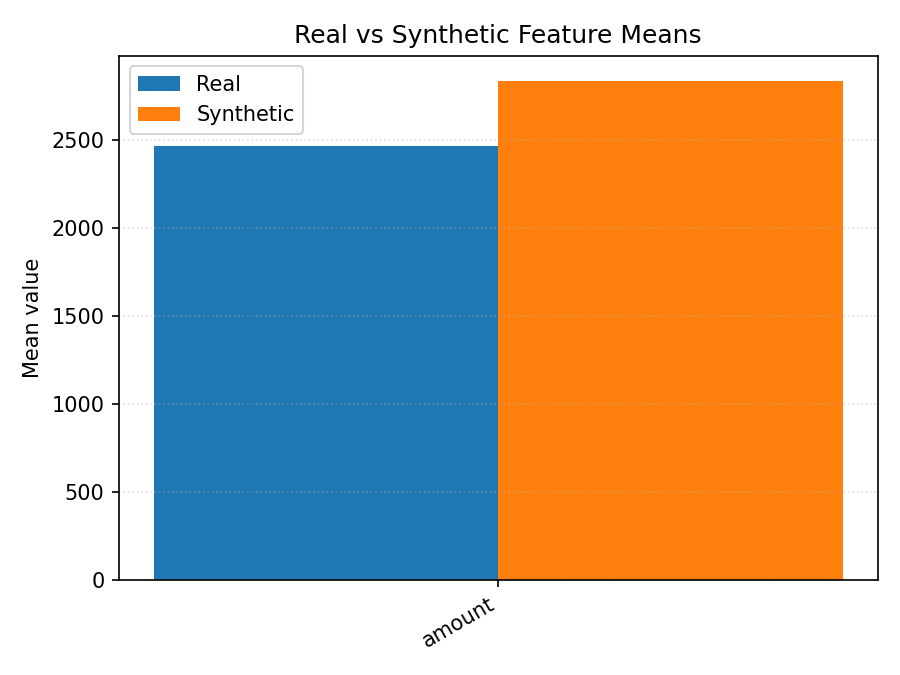

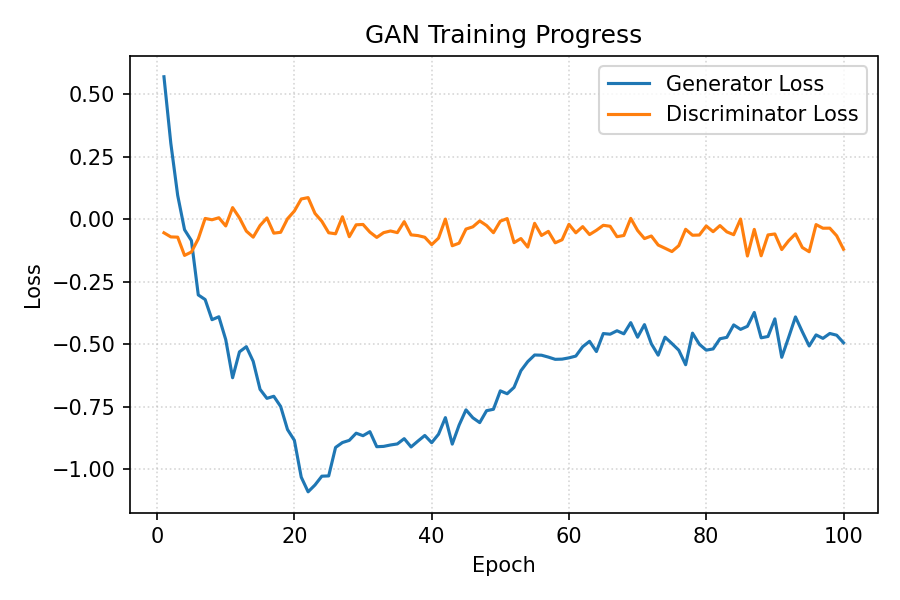

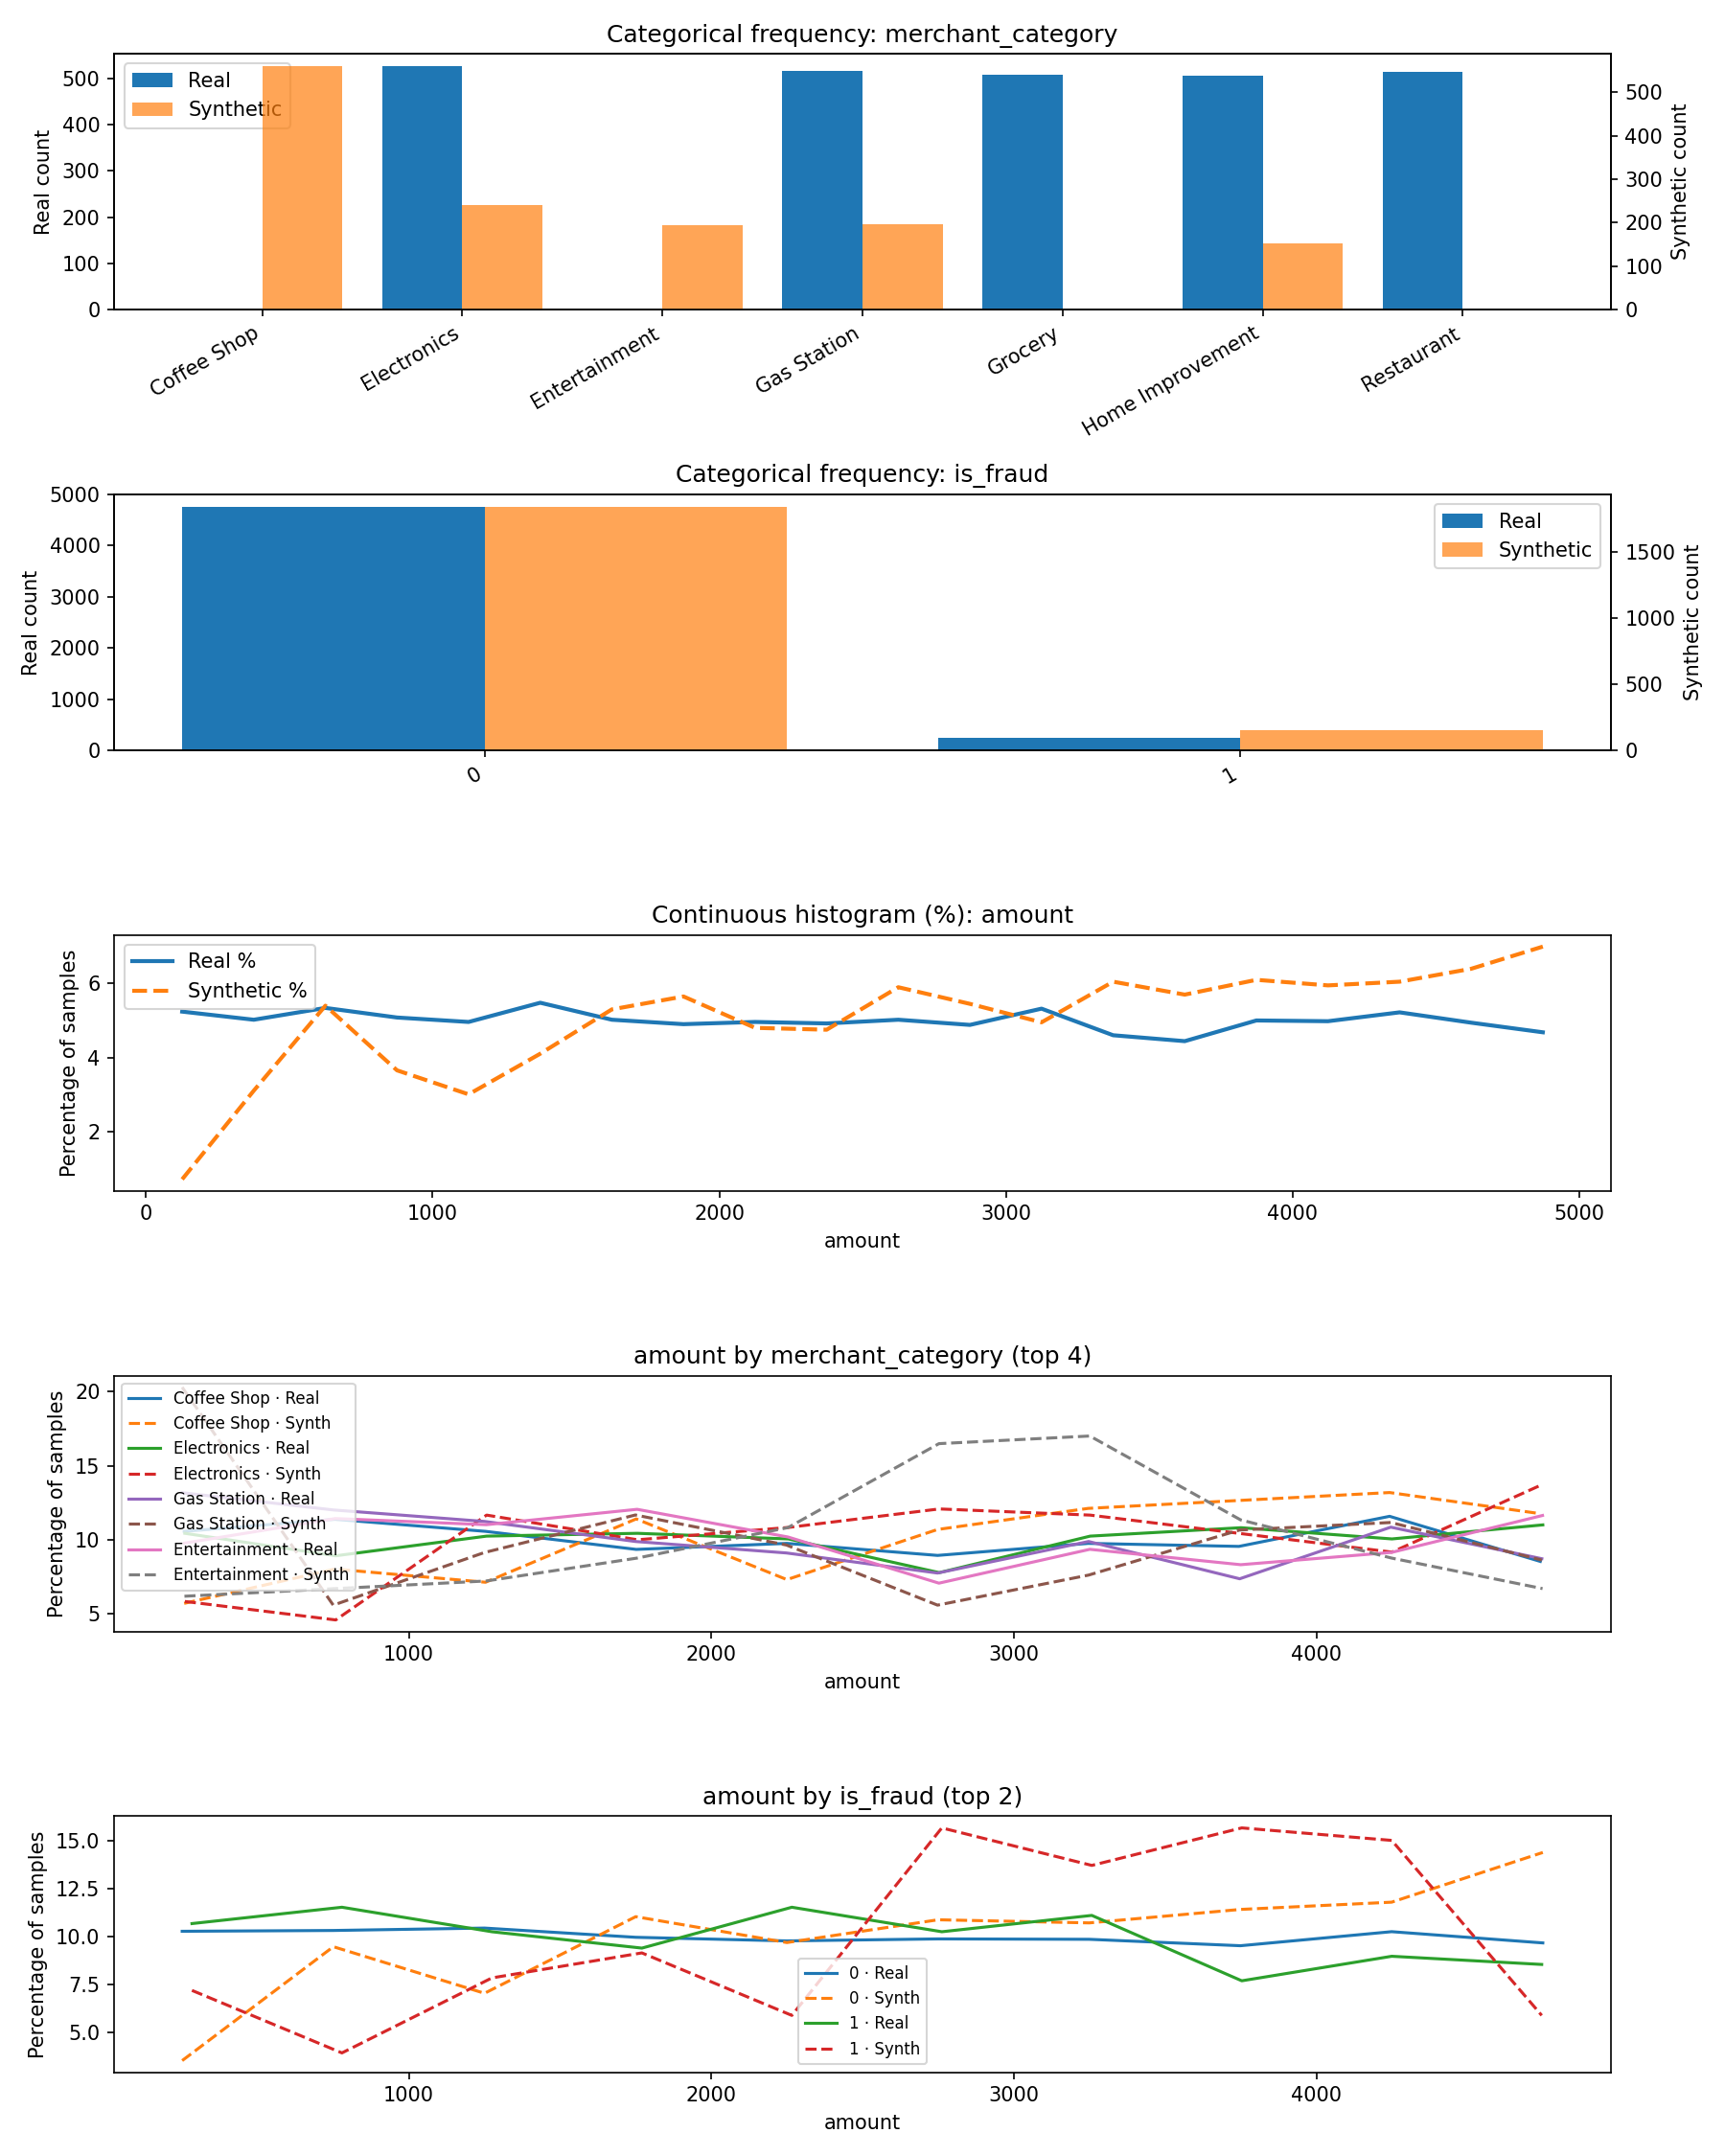

In [5]:
result = generate_synthetic_transactions(
    data_path=data_path,
    output_path=output_path,
    schema=schema,
    gan_config=gan_config,
    samples_to_generate=2000,
    train_fraction=0.5,
    split_seed=split_seed,
    auto_tune=False,
    validation_fraction=0.2,
    tstr_target='is_fraud',
)
display(JSON(result['quality_report']))
display(result['synthetic_preview'])
print('Synthetic CSV stored at:', result['synthetic_path'])
print('Metrics JSON stored at:', result['metrics_path'])
print('Testing report stored at:', result['testing_report_path'])
display(Image(filename=result['visualization_path']))
display(Image(filename=result['training_history_path']))
display(Image(filename=result['testing_visualization_path']))


In [6]:
result['split_summary']


{'train_fraction': 0.5,
 'train_size': 5000,
 'holdout_size': 5000,
 'split_seed': 123}

In [7]:
history = result['training_history']
{"epochs": history.get('epochs', [])[:5], "generator": history.get('generator', [])[:5], "discriminator": history.get('discriminator', [])[:5]}


{'epochs': [0.0, 1.0, 2.0, 3.0, 4.0],
 'generator': [0.5690082311630249,
  0.30264052748680115,
  0.09461718797683716,
  -0.04288959503173828,
  -0.08629155158996582],
 'discriminator': [-0.055220797657966614,
  -0.07156997919082642,
  -0.07260370254516602,
  -0.14560508728027344,
  -0.13198822736740112]}

In [8]:
result['tstr_scores'], result['selected_gan_config'], result.get('tuning_history')


({'accuracy': 0.9496, 'f1': 0.48707427164546574},
 {'noise_dim': 64,
  'hidden_dim': 128,
  'epochs': 100,
  'learning_rate': 0.0002,
  'batch_size': 250,
  'pac': 1,
  'generator_dims': None,
  'discriminator_dims': None,
  'use_cuda': True},
 [])

In [9]:
testing_report = json.loads(Path(result['testing_report_path']).read_text())
testing_report


{'train': {'categorical_frequencies': {'merchant_category': {'real': {'Electronics': 527,
     'Gas Station': 516,
     'Restaurant': 514,
     'Grocery': 508,
     'Home Improvement': 506},
    'synthetic': {'Coffee Shop': 561,
     'Electronics': 240,
     'Gas Station': 197,
     'Entertainment': 194,
     'Home Improvement': 153}},
   'is_fraud': {'real': {'0': 4766, '1': 234},
    'synthetic': {'0': 1847, '1': 153}}},
  'continuous_histograms': {'amount': {'real': {'bins': [1.03,
      250.91700000000003,
      500.80400000000003,
      750.691,
      1000.5780000000001,
      1250.4650000000001,
      1500.352,
      1750.2390000000003,
      2000.1260000000002,
      2250.0130000000004,
      2499.9000000000005,
      2749.7870000000007,
      2999.6740000000004,
      3249.5610000000006,
      3499.448000000001,
      3749.3350000000005,
      3999.2220000000007,
      4249.109,
      4498.996,
      4748.883000000001,
      4998.77],
     'counts': [262,
      251,
      267,
